In [43]:
# this file shows how to process 3D movement directly 
# without performing alignment 
# in this case, "match_points_gui.py" must be run once to match points to track
# but no other pre-processing steps should be required (other than system calibration)

In [44]:
from hsflfm.util import load_dictionary, save_dictionary, MetadataManager
from hsflfm.processing import StrikeProcessor 

import os 
from tqdm import tqdm 
import numpy as np 
from matplotlib import pyplot as plt 

In [ ]:
# Choose Specimen Here

specimen = "20260602_B_1"

# Save all processed result folders inside one parent directory
results_parent_folder = "../processed_results"

save_folder = f"{results_parent_folder}/results_{specimen}"
print(save_folder)

../processed_results/results_20260602_B_1


In [47]:
from pathlib import Path

def get_save_filename(specimen_number, strike_number, save_folder):
    save_folder = Path(save_folder)
    spec_folder = save_folder / specimen_number

    spec_folder.mkdir(parents=True, exist_ok=True)

    filename = spec_folder / f"strike_{int(strike_number)}_results.json"
    return str(filename)

In [ ]:

mm = MetadataManager(specimen) 
print(mm.match_points_filename)
match_points = load_dictionary(mm.match_points_filename)
results = {
    "match_points": match_points, 
    "specimen_number": specimen,
}

for strike_number in tqdm(mm.strike_numbers):
    results["strike_number"] = strike_number
    save_filename = get_save_filename(specimen, strike_number, save_folder)

    processor = StrikeProcessor(results.copy()) 
    processor.get_flow_vectors() 
    processor.run_regression() 
    result_info = processor.condense_info(displacements_only=True) 
    save_dictionary(result_info, save_filename)


C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260602_B/match_points


100%|██████████| 1/1 [00:05<00:00,  5.62s/it]


In [ ]:
# Check results file save path
print(os.path.abspath(save_filename))

c:\Users\abhin\HighSpeedFLFM\processed_results\results_20260602_B_1\20260602_B_1\strike_1_results.json


In [50]:
# Verify match points are loaded correctly 
print(match_points.keys())
for cam, pts in match_points.items():
    print(cam, np.asarray(pts).shape)

dict_keys([0, 1, 2, 3, 4, 5])
0 (19, 5)
1 (19, 5)
2 (19, 5)
3 (19, 5)
4 (19, 5)
5 (19, 5)


In [51]:
# XYZ start positions for points
print(processor.start_positions.shape)
print("NaNs in start_positions:", np.isnan(processor.start_positions).any())
print(processor.start_positions)

(19, 3)
NaNs in start_positions: False
[[5.08840243 7.4445704  0.82779552]
 [5.39987863 7.34117186 0.82775025]
 [5.71134571 6.92757559 0.82777226]
 [5.29602977 6.41058028 0.82794313]
 [4.9326387  6.358881   0.82799914]
 [4.30970358 7.49626744 0.82792193]
 [4.05012378 6.56567764 0.82806771]
 [3.47908238 6.77247279 0.82808812]
 [4.10209091 5.47999049 0.82902794]
 [3.79058329 8.84044679 0.82780522]
 [7.2167552  4.29089392 0.82793678]
 [6.23042265 1.70592093 0.82862812]
 [4.77689884 1.55083651 0.8290069 ]
 [6.59383414 5.79018339 0.82782956]
 [7.26871525 6.41057689 0.82753851]
 [6.85348284 8.89217651 0.82689181]
 [6.23053589 8.99557762 0.82714672]
 [8.46272854 3.15350126 0.82802815]
 [3.68677286 1.39575718 0.82922431]]


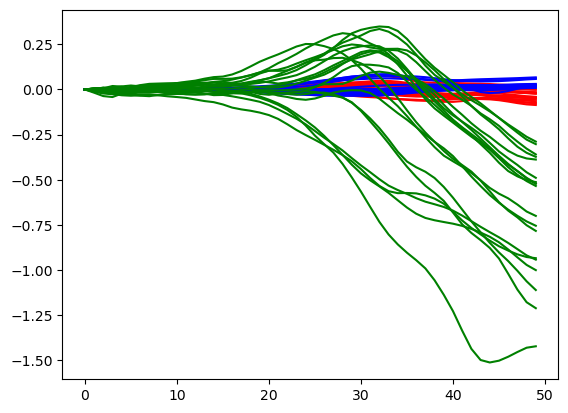

In [ ]:
# View XYZ dispalcements for camera points
displacements = np.asarray(result_info["camera_point_displacements"])

for dim, color in enumerate(["red", "blue", "green"]):
    for p in displacements:
        plt.plot(p[:, dim], color=color)

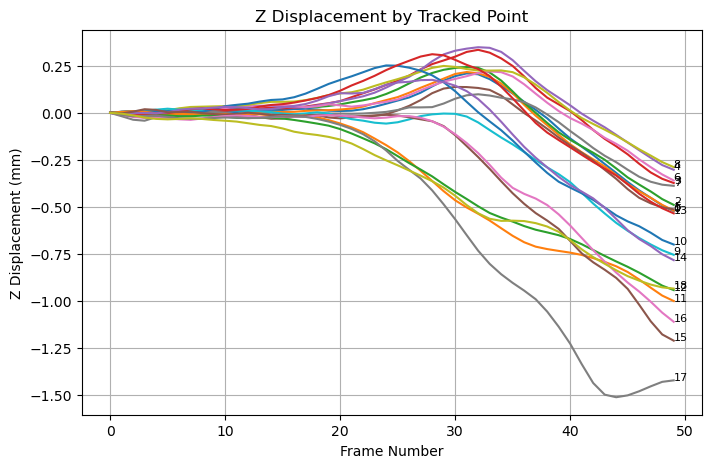

In [53]:
displacements = np.asarray(result_info["camera_point_displacements"])

# Plot only z displacement, labeled by point number
plt.figure(figsize=(8, 5))

for point_num, p in enumerate(displacements):
    z = p[:, 2]
    plt.plot(z, label=f"Point {point_num}")
    plt.text(len(z) - 1, z[-1], str(point_num), fontsize=8)

plt.xlabel("Frame Number")
plt.ylabel("Z Displacement (mm)")
plt.title("Z Displacement by Tracked Point")
plt.grid(True)
plt.show()

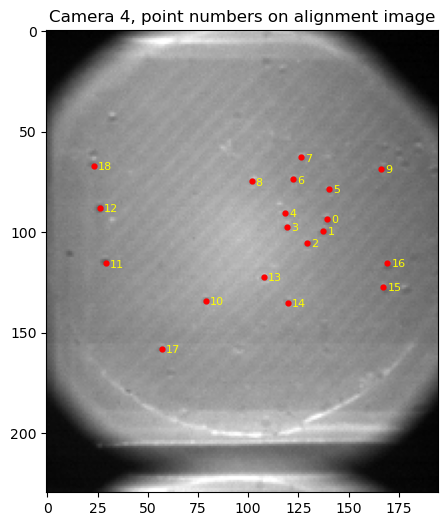

In [ ]:
# See where numbered points from above image are located on the specimen 

from hsflfm.util import load_image_set
from hsflfm.calibration import CalibrationInfoManager

cam_num = 4  # change to inspect other views

calibration_manager = CalibrationInfoManager(mm.calibration_filename)
image_filename = mm.light_calibration_filename

alignment_images = load_image_set(
    filename=image_filename,
    calibration_filename=mm.calibration_filename,
    image_numbers=[cam_num],
)

image = alignment_images[cam_num]
pts = np.asarray(result_info["match_points"][cam_num])

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")

plt.scatter(pts[:, 1], pts[:, 0], s=12, c="r")

for point_num, p in enumerate(pts):
    plt.text(
        p[1] + 2,
        p[0] + 2,
        str(point_num),
        color="yellow",
        fontsize=8,
    )

plt.title(f"Camera {cam_num}, point numbers on alignment image")
plt.show()

In [1]:
## Use when testing manual translation of specimen to confirm displacements are accurate 

# displacements = np.asarray(result_info["camera_point_displacements"])

# labels = ["X displacement", "Y displacement", "Z displacement"]
# colors = ["red", "blue", "green"]

# x = np.arange(41)
# y = -x * 0.1

# plt.figure(figsize=(8, 5))

# for dim, (color, label) in enumerate(zip(colors, labels)):
#     for i, p in enumerate(displacements):
#         if i == 0:
#             plt.plot(p[:, dim], color=color, label=label)
#         else:
#             plt.plot(p[:, dim], color=color)


# plt.plot(x, y, '.-')
# plt.xlabel("Frame Number")
# plt.ylabel("Displacement (mm)")
# plt.title("Point Displacements")
# plt.legend()
# plt.grid(True)

# plt.show()